In [ ]:
import pandas as pd
import torch
from sklearn.model_selection import train_test_split
from transformers import DistilBertTokenizerFast, DistilBertForSequenceClassification, Trainer, TrainingArguments
import re
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


,Unnamed: 0,patient_id,drugName,condition,review,rating,date,usefulCount,review_length
0,0,163740,Mirtazapine,depression,"""i've tried a few antidepressants over the yea...",10.0,"February 28, 2012",22,68
1,1,206473,Mesalamine,"crohn's disease, maintenance","""my son has crohn's disease and has done very ...",8.0,"May 17, 2009",17,48
2,2,39293,Contrave,weight loss,"""contrave combines drugs that were used for al...",9.0,"March 5, 2017",35,143
3,3,97768,Cyclafem 1 / 35,birth control,"""i have been on this birth control for one cyc...",9.0,"October 22, 2015",4,149
4,4,208087,Zyclara,keratosis,"""4 days in on first 2 weeks. using on arms an...",4.0,"July 3, 2014",13,60


In [ ]:


rating = dict(df.loc[df.rating == 10, "drugName"].value_counts())
drugname = list(rating.keys())[:20]
drug_rating = list(rating.values())[:20]


plot_df = pd.DataFrame({
    "Drug Name": drugname,
    "Number of Ratings": drug_rating
})


fig = px.bar(
    plot_df,
    x="Drug Name",
    y="Number of Ratings",
    title="Top 20 Drugs with 10/10 Rating",
    labels={"Drug Name": "Drug Names"},
    template="plotly_dark"
)

fig.update_layout(
    xaxis_tickangle=-90,
    height=600,
    width=1000
)

fig.show()


In [ ]:
import plotly.express as px
import pandas as pd

rating_counts = df['rating'].value_counts().reset_index()
rating_counts.columns = ['Rating', 'Count']
fig = px.pie(rating_counts,
             names='Rating',
             values='Count',
             title='Rating Distribution',
             color_discrete_sequence=px.colors.sequential.RdBu,
             width=600, height=400)

fig.show()

In [ ]:
import plotly.express as px

df['sentiment'] = df['rating'].apply(lambda x: 1 if x >= 6 else 0)

sentiment_counts = df['sentiment'].value_counts().reset_index()
sentiment_counts.columns = ['Sentiment', 'Count']

sentiment_counts['Sentiment'] = sentiment_counts['Sentiment'].map({1: 'positive', 0: 'negative'})

fig = px.bar(
    sentiment_counts,
    x='Sentiment',
    y='Count',
    text='Count',
    title='Sentiment Distribution Derived from Ratings',
    color='Sentiment',
    color_discrete_map={
        'positive': 'green',
        'negative': 'red'
    }
)
fig.update_layout(
    xaxis_title='Sentiment',
    yaxis_title='Number of Reviews',
    title_font_size=20,
    plot_bgcolor='rgba(0,0,0,0)',
    yaxis=dict(gridcolor='lightgrey'),
    width=800,
    height=500
)

fig.update_traces(textposition='outside')


fig.show()

In [ ]:
if 'Unnamed: 0' in df.columns:
    df.drop(columns=['Unnamed: 0'], inplace=True)


print(df.describe())

print(df.info())

print(df.isnull().mean())

print(df.shape)


          patient_id        rating   usefulCount  review_length     sentiment
count   46108.000000  46108.000000  46108.000000   46108.000000  46108.000000
mean   116604.217988      6.980979     28.505270      95.415156      0.699857
std     66906.119983      3.256990     37.222459      37.716939      0.458325
min         0.000000      1.000000      0.000000      31.000000      0.000000
25%     59070.750000      5.000000      6.000000      63.000000      0.000000
50%    116932.500000      8.000000     16.000000      95.000000      1.000000
75%    174279.000000     10.000000     37.000000     130.000000      1.000000
max    232284.000000     10.000000    949.000000    1162.000000      1.000000
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 46108 entries, 0 to 46107
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   patient_id     46108 non-null  int64  
 1   drugName       46108 non-null  object 
 2   condition

In [ ]:

df.columns = df.columns.str.strip()
columns_to_drop = ['patient_id', 'drugName', 'condition', 'date', 'usefulCount','review_length']
df.drop(columns=[col for col in columns_to_drop if col in df.columns], inplace=True)
print(df.head())

                                              review  rating  sentiment
0  "i've tried a few antidepressants over the yea...    10.0          1
1  "my son has crohn's disease and has done very ...     8.0          1
2  "contrave combines drugs that were used for al...     9.0          1
3  "i have been on this birth control for one cyc...     9.0          1
4  "4 days in on first 2 weeks.  using on arms an...     4.0          0


In [ ]:
import re
def clean_text(text):
    text = text.lower()
    text = re.sub(r"<.*?>", "", text)
    text = re.sub(r"http\S+", "", text)
    text = re.sub(r"[^a-z\s]", "", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text


df['clean_review'] = df['review'].apply(clean_text)


df['sentiment'] = df['rating'].apply(lambda x: 1 if x >= 6 else 0)


df.head()

,review,rating,sentiment,clean_review
0,"""i've tried a few antidepressants over the yea...",10.0,1,ive tried a few antidepressants over the years...
1,"""my son has crohn's disease and has done very ...",8.0,1,my son has crohns disease and has done very we...
2,"""contrave combines drugs that were used for al...",9.0,1,contrave combines drugs that were used for alc...
3,"""i have been on this birth control for one cyc...",9.0,1,i have been on this birth control for one cycl...
4,"""4 days in on first 2 weeks. using on arms an...",4.0,0,days in on first weeks using on arms and face ...


In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(max_features=5000, ngram_range=(1, 2))
clean_review_vect = vectorizer.fit_transform(df['clean_review'])

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(clean_review_vect, df['sentiment'], test_size=0.2, random_state=42)

In [ ]:
from sklearn.linear_model import LogisticRegression

modellr = LogisticRegression()
modellr.fit(X_train, y_train)


LogisticRegression()

In [ ]:
y_pred = modellr.predict(X_test)

0.8511168943829972
              precision    recall  f1-score   support

           0       0.82      0.66      0.73      2811
           1       0.86      0.93      0.90      6411

    accuracy                           0.85      9222
   macro avg       0.84      0.80      0.81      9222
weighted avg       0.85      0.85      0.85      9222

[[1856  955]
 [ 418 5993]]


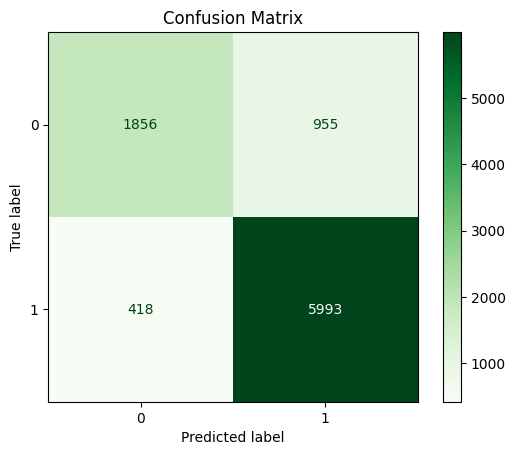

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
print(accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)


disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap=plt.cm.Greens)
plt.title("Confusion Matrix")
plt.show()


In [ ]:
from sklearn.svm import LinearSVC
svm_model = LinearSVC(C=1.0, max_iter=10000)
svm_model.fit(X_train, y_train)


LinearSVC(max_iter=10000)

Accuracy: 0.8500325309043592

Classification Report:
               precision    recall  f1-score   support

           0       0.78      0.71      0.74      2811
           1       0.88      0.91      0.89      6411

    accuracy                           0.85      9222
   macro avg       0.83      0.81      0.82      9222
weighted avg       0.85      0.85      0.85      9222


Confusion Matrix:
 [[1997  814]
 [ 569 5842]]


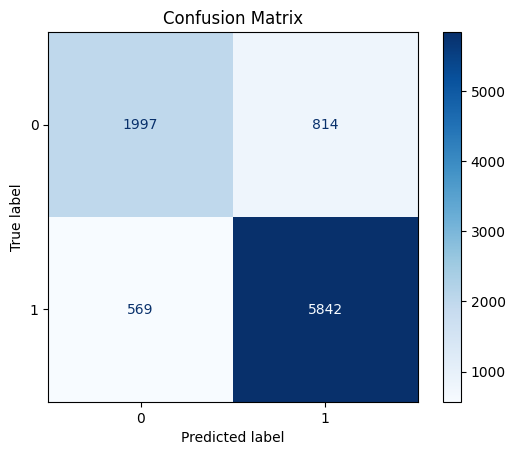

In [ ]:


y_pred = svm_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)


disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix")
plt.show()

In [ ]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(use_label_encoder=False, eval_metric='logloss')
xgb_model.fit(X_train, y_train)

/usr/local/lib/python3.11/dist-packages/xgboost/training.py:183: UserWarning:

[06:32:11] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.




XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, ...)

Accuracy: 0.8322489698546953

Classification Report:
               precision    recall  f1-score   support

           0       0.82      0.58      0.68      2811
           1       0.84      0.94      0.89      6411

    accuracy                           0.83      9222
   macro avg       0.83      0.76      0.78      9222
weighted avg       0.83      0.83      0.82      9222


Confusion Matrix:
 [[1634 1177]
 [ 370 6041]]


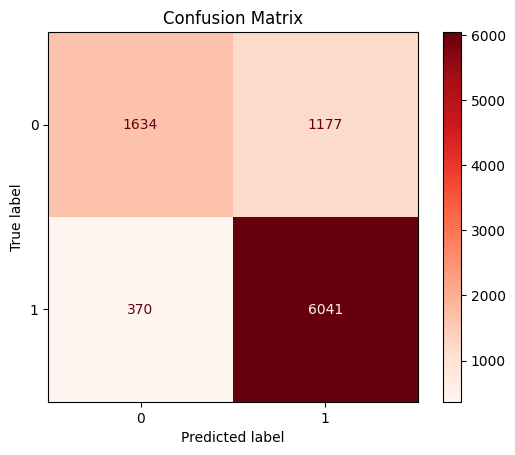

In [ ]:

y_pred = xgb_model.predict(X_test)


print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)


disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap=plt.cm.Reds)
plt.title("Confusion Matrix")
plt.show()


***NOW USING LLM MODEL DistilBERT ***

In [ ]:
# Split into train_test
X_train, X_test, y_train, y_test = train_test_split(
    df['clean_review'].tolist(), df['sentiment'].tolist(), test_size=0.2, random_state=42
)

In [ ]:
from transformers import DistilBertTokenizerFast

tokenizer = DistilBertTokenizerFast.from_pretrained("distilbert-base-uncased")

train_encodings = tokenizer(X_train, truncation=True, padding=True, max_length=128)
test_encodings = tokenizer(X_test, truncation=True, padding=True, max_length=128)

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning:


The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.



tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

In [ ]:
import torch
from torch.utils.data import Dataset

class CustomDataset(Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels


    def __getitem__(self, idx):
        item = {
            "input_ids": torch.tensor(self.encodings["input_ids"][idx]),
            "attention_mask": torch.tensor(self.encodings["attention_mask"][idx]),
            "labels": torch.tensor(self.labels[idx], dtype=torch.long) # Ensure labels are long type
        }
        return item

    def __len__(self):
        return len(self.labels)

In [ ]:
train_dataset = CustomDataset(train_encodings, y_train)
eval_dataset = CustomDataset(test_encodings, y_test)


model = DistilBertForSequenceClassification.from_pretrained("distilbert-base-uncased", num_labels=2)

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [ ]:
from transformers import TrainingArguments

training_args = TrainingArguments(
    warmup_steps=500,
    learning_rate=3e-5,
    output_dir='./results',
    num_train_epochs=3,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    gradient_accumulation_steps=2,
    weight_decay=0.01,
    eval_strategy="epoch",
    logging_dir='./logs',
    logging_steps=8,
    logging_strategy="steps",
    save_strategy="epoch",
    report_to=None,
    lr_scheduler_type="linear",
    load_best_model_at_end=True,
    metric_for_best_model="accuracy" )

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = logits.argmax(-1)
    return {
        "accuracy": accuracy_score(labels, preds),
        "precision": precision_score(labels, preds, average='weighted'),
        "recall": recall_score(labels, preds, average='weighted'),
        "f1": f1_score(labels, preds, average='weighted'),
    }

In [ ]:
from transformers import Trainer
from transformers.trainer_callback import EarlyStoppingCallback

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=eval_dataset,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)]
)


trainer.train()



wandb: WARNING The `run_name` is currently set to the same value as `TrainingArguments.output_dir`. If this was not intended, please specify a different run name by setting the `TrainingArguments.run_name` parameter.


<IPython.core.display.Javascript object>

wandb: Logging into wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: You can find your API key in your browser here: https://wandb.ai/authorize?ref=models
wandb: Paste an API key from your profile and hit enter:

 ··········


wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: 1604rahulpatel (1604rahulpatel-chhattisgarh-swami-vivekanand-technical-u) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.347100,0.290025,0.876599,0.875030,0.876599,0.875455
2,0.295100,0.266487,0.891021,0.891076,0.891021,0.891049
3,0.106400,0.303231,0.895467,0.895617,0.895467,0.895540


TrainOutput(global_step=3459, training_loss=0.2641835331951273, metrics={'train_runtime': 1269.6548, 'train_samples_per_second': 87.156, 'train_steps_per_second': 2.724, 'total_flos': 3664644350118912.0, 'train_loss': 0.2641835331951273, 'epoch': 3.0})

In [ ]:
results = trainer.evaluate()
print("Evaluation Results:", results)


Evaluation Results: {'eval_loss': 0.3032307028770447, 'eval_accuracy': 0.895467360659293, 'eval_precision': 0.8956174162917907, 'eval_recall': 0.895467360659293, 'eval_f1': 0.8955400612489908, 'eval_runtime': 28.794, 'eval_samples_per_second': 320.275, 'eval_steps_per_second': 20.039, 'epoch': 3.0}


In [ ]:
import numpy as np
predictions = trainer.predict(eval_dataset)
y_test = predictions.label_ids
y_pred = np.argmax(predictions.predictions, axis=1)


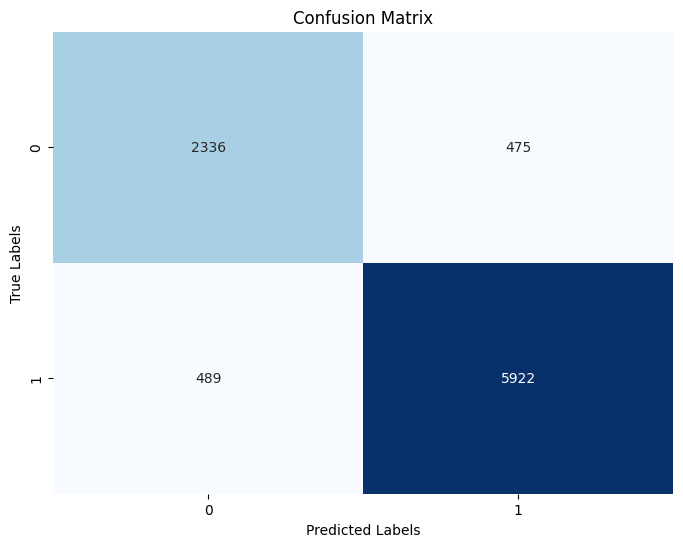

0.895467360659293


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)


plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix')
plt.show()

print(accuracy_score(y_test, y_pred))

In [ ]:
y_proba = predictions.predictions[:, 1]

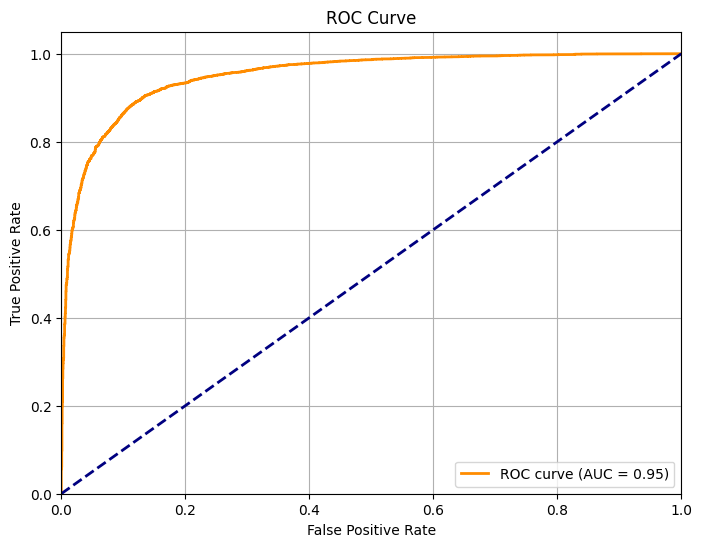

In [ ]:
from sklearn.metrics import roc_curve, auc, RocCurveDisplay

# Compute ROC curve and AUC
fpr, tpr, thresholds = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)

# Plot
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')  # Diagonal line
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()


In [ ]:
# Save the trained model
trainer.save_model("./sentiment_model")

In [ ]:
from transformers import DistilBertTokenizerFast, DistilBertForSequenceClassification, TensorType
import torch
import torch.nn.functional as F

model_path = "./sentiment_model"
model = DistilBertForSequenceClassification.from_pretrained(model_path)

tokenizer = DistilBertTokenizerFast.from_pretrained("distilbert-base-uncased")
model.eval()


def predict_sentiment(text):

    clean_text_input = clean_text(text)


    inputs = tokenizer(clean_text_input, return_tensors=TensorType.PYTORCH, truncation=True, padding=True, max_length=128)


    with torch.no_grad():
        outputs = model(**inputs)
        logits = outputs.logits
        probabilities = F.softmax(logits, dim=1)
        predicted_class = torch.argmax(probabilities, dim=1).item()


    sentiment = "positive" if predicted_class == 1 else "negative"
    return sentiment


new_review = "This drug worked wonders for me!"
predicted_sentiment = predict_sentiment(new_review)
print(f"The sentiment of the review '{new_review}' is: {predicted_sentiment}")

new_review_2 = " this medicine  causes sever damages to my kidney and lungs"
predicted_sentiment_2 = predict_sentiment(new_review_2)
print(f"The sentiment of the review '{new_review_2}' is: {predicted_sentiment_2}")

The sentiment of the review 'This drug worked wonders for me!' is: positive
The sentiment of the review ' this medicine  causes sever damages to my kidney and lungs' is: negative


In [ ]:

model_accuracies = {
    'Logistic Regression': 0.8511,
    'SVM': 0.8505,
    'XGBoost': 0.8302,
    'DistilBERT': 0.8954
}


accuracy_df = pd.DataFrame(list(model_accuracies.items()), columns=['Model', 'Accuracy'])


fig = px.bar(
    accuracy_df,
    x='Model',
    y='Accuracy',
    text='Accuracy',
    title='Comparison of Model Accuracies',
    color='Model',
    color_discrete_sequence=px.colors.qualitative.Set2
)


fig.update_layout(
    yaxis=dict(range=[0, 1], title='Accuracy'),
    xaxis_title='Models',
    title_font_size=20,
    plot_bgcolor='rgba(0,0,0,0)',
    width=800,
    height=500
)

fig.update_traces(texttemplate='%{text:.2%}', textposition='outside')
fig.show()